# Convert Registration Transform Results to OME-Zarr Transforms

`itk-elastix` builds on tools available in the Insight Toolkit image processing ecosystem to deliver advanced registration methods. [Example 22](./ITK_Example22_ConvertToITKTransform.ipynb) showed how Elastix registration results are converted to standard ITK transform types. This notebook takes the next step and stores those ITK transforms as **OME-Zarr coordinate transformations** with [`ngff-zarr`](https://ngff-zarr.readthedocs.io/), so that registration results travel with the image in an open, chunked, cloud-ready format.

[OME-NGFF RFC-5](https://ngff-zarr.readthedocs.io/en/latest/rfc5.html), part of OME-Zarr 0.6, adds named *coordinate systems* and *coordinate transformations* to the multiscales metadata. A transformation maps an *input* coordinate system to an *output* coordinate system, and RFC-5 defines the transformation types `identity`, `scale`, `translation`, `rotation`, `affine`, `sequence`, `displacements`, `coordinates` and more. Two of them matter for registration results:

- **`affine`** represents any linear registration result (translation, rigid, similarity or affine stages) as a single matrix.
- **`displacements`** represents a deformable result as a displacement field: a multiscale image stored in the OME-Zarr group, with one component per spatial axis, that the transformation points at by `path`.

The conversion pipeline demonstrated here is:

1. Elastix parameter maps drive `itk.ElastixRegistrationMethod`.
2. `ConvertToItkTransform` turns the Elastix result into an `itk.CompositeTransform`.
3. `ngff_zarr.itk_transform_to_ngff_transform` converts the linear stages into an RFC-5 `affine`, and `ngff_zarr.itk_displacement_field_to_ngff_transform` converts the full deformable result into an RFC-5 `displacements` field.
4. The transformation is attached to the image's multiscales metadata and written with `ngff_zarr.to_ome_zarr(..., version="0.6")`.

This notebook requires `ngff-zarr` 0.48 or newer, which supports Python 3.11 and later:

```
pip install itk-elastix "ngff-zarr>=0.48"
```

In [1]:
import json
import shutil
from pathlib import Path

import itk
import matplotlib.pyplot as plt
import ngff_zarr as nz
import numpy as np
from ngff_zarr import CoordinateSystem, CoordinateSystemIdentifier

%matplotlib inline

## Load Images

For demonstration we will perform deformable registration of a moving image onto a distorted, fixed image, as in Example 22.

In [2]:
# Load images with itk floats (itk.F). Necessary for elastix
fixed_image = itk.imread("data/CT_2D_head_fixed.mha", itk.F)
moving_image = itk.imread("data/CT_2D_head_moving.mha", itk.F)

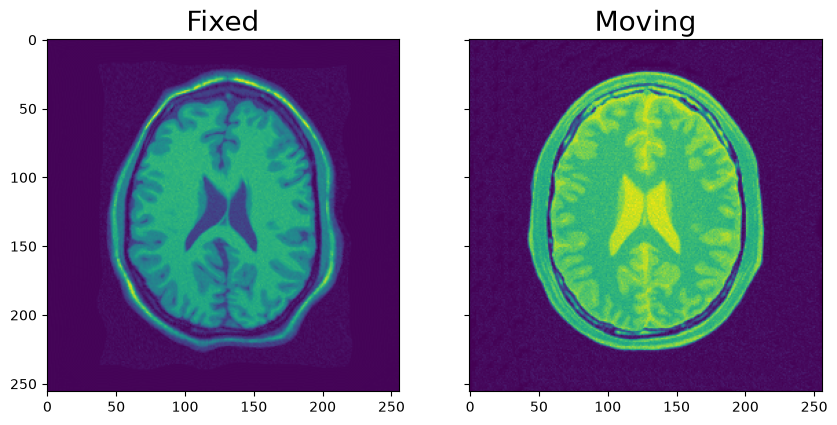

In [3]:
# Plot images
fig, axs = plt.subplots(1, 2, sharey=True, figsize=[10, 5])
axs[0].imshow(fixed_image)
axs[0].set_title("Fixed", fontsize=20)
axs[1].imshow(moving_image)
axs[1].set_title("Moving", fontsize=20)
plt.show()

## Set Up and Run Registration

We optimize the same three-stage transform schedule as Example 22, with the default Elastix parameter map for each stage:

1. Rigid (Euler2D) registration optimizing a global translation and rotation
2. Affine registration optimizing a global translation, rotation, scale, and shear
3. B-Spline registration optimizing local alignment with spline-based deformations

Registration optimizes a transform that maps physical points _from the fixed image space to the moving image space_. This is the direction needed to resample the moving image onto the fixed image grid, and it is also the direction of the RFC-5 transformations written below: from the fixed image's coordinate system to the moving image's coordinate system.

In [4]:
parameter_object = itk.ParameterObject.New()
for transform_name in ("rigid", "affine", "bspline"):
    parameter_object.AddParameterMap(
        itk.ParameterObject.GetDefaultParameterMap(transform_name)
    )

In [5]:
# We retain a handle to the `registration_method` object for subsequent transform output conversion methods.
registration_method_type = itk.ElastixRegistrationMethod[
    type(fixed_image), type(moving_image)
]
registration_method = registration_method_type.New(
    fixed_image=fixed_image,
    moving_image=moving_image,
    parameter_object=parameter_object,
)
registration_method.Update()
elx_result_image = registration_method.GetOutput()

## Get Registration Results as an ITK Transform

As in Example 22, the Elastix combination transform is converted to an `itk.CompositeTransform`. ITK applies the *last* transform in the queue first, so the queue holds the B-spline, affine and rigid stages in that order: a fixed-space point is first moved by the rigid stage, then by the affine stage, and finally by the B-spline stage.

In [6]:
elx_advanced_transform = registration_method.GetCombinationTransform()
itk_composite_transform = itk.CompositeTransform[itk.D, 2].cast(
    registration_method.ConvertToItkTransform(elx_advanced_transform)
)

n_stages = itk_composite_transform.GetNumberOfTransforms()
print("Composite transform queue (ITK applies the last entry first):")
for index in range(n_stages):
    stage = itk_composite_transform.GetNthTransform(index)
    print(f"  [{index}] {stage.GetNameOfClass()}")

Composite transform queue (ITK applies the last entry first):
  [0] BSplineTransform
  [1] AffineTransform
  [2] Euler2DTransform


## Describe the Images to ngff-zarr

`ngff-zarr` represents an image as an `NgffImage`: a Dask array together with dimension names, per-axis `scale` and `translation`, optional units, and optional [RFC-4](https://ngff-zarr.readthedocs.io/en/latest/rfc4.html) anatomical orientation. `itk_image_to_ngff_image` derives all of these from the ITK image's spacing, origin and direction.

Dimension names follow the array's storage order: `('y', 'x')` for a 2D image and `('z', 'y', 'x')` for a 3D image. This is also the order in which RFC-5 transformation parameters are expressed.

In [7]:
fixed_ngff = nz.itk_image_to_ngff_image(fixed_image)
moving_ngff = nz.itk_image_to_ngff_image(moving_image)

print("dims:", fixed_ngff.dims)
print("scale:", fixed_ngff.scale)
print("translation:", fixed_ngff.translation)
print("orientation:", {dim: o.value.value for dim, o in fixed_ngff.axes_orientations.items()})

dims: ('y', 'x')
scale: {'y': 1.0, 'x': 1.0}
translation: {'y': 0.0, 'x': 0.0}
orientation: {'y': 'anterior-to-posterior', 'x': 'right-to-left'}


## Conventions: ITK Transforms versus RFC-5 Transformations

An ITK transform and an RFC-5 transformation describe the same geometry with different conventions. `ngff-zarr` reconciles them during conversion, and knowing them helps to interpret the results:

- **Axis order.** ITK orders the components of a point fastest axis first: x, then y, then z. RFC-5 parameters follow the axis order of the coordinate system, `y, x` here. The rows and columns of the matrix and the offset are permuted accordingly.
- **Center of rotation.** ITK's matrix-offset transforms evaluate `y = A (x - c) + t + c` with a center of rotation `c`. An RFC-5 `affine` has no center, so it is folded into the offset: `b = t + c - A c`.
- **Composition order.** `itk.CompositeTransform` applies its last entry first, whereas an RFC-5 `sequence` applies its first entry first. `ngff-zarr` avoids the ambiguity by collapsing the linear stages into a single matrix.
- **Coordinate spaces.** An ITK transform acts on physical space, which includes the image direction matrix. An RFC-5 transformation acts between named coordinate systems, and an image's *intrinsic* coordinate system is the one reached from array indices through the dataset's `scale` and `translation`. Passing the fixed and moving `NgffImage`s to the converter lets it change frames exactly, which matters when the images carry a non-identity direction (RFC-4 anatomical orientation).
- **Direction.** Like the ITK transform, the RFC-5 transformation maps *fixed* coordinates to *moving* coordinates.

## Linear Registration Stages to an RFC-5 `affine`

An RFC-5 `affine` can hold any *linear* transform, so it can represent the rigid and affine stages but not the B-spline stage. Elastix stages are cumulative: the composite of the rigid and affine stages is exactly the registration result after the second stage. We collect the linear stages into their own `itk.CompositeTransform`, preserving their order, and convert it.

In [8]:
linear_transform = itk.CompositeTransform[itk.D, 2].New()
for index in range(n_stages):
    stage = itk_composite_transform.GetNthTransform(index)
    if stage.IsLinear():
        linear_transform.AddTransform(stage)

print(
    [
        linear_transform.GetNthTransform(index).GetNameOfClass()
        for index in range(linear_transform.GetNumberOfTransforms())
    ]
)

['AffineTransform', 'Euler2DTransform']


In [9]:
affine = nz.itk_transform_to_ngff_transform(
    linear_transform,
    fixed_ngff.dims,
    fixed=fixed_ngff,
    moving=moving_ngff,
)
affine

Affine(input=None, output=None, name=None, type='affine', affine=[[1.0012793534350397, -0.012046404382801563, 1.3200023891498776], [0.00048439287451264713, 1.0002052036162588, -1.1264402073727322]], path=None)

The result is an RFC-5 `Affine` dataclass. Its `affine` field holds the `M x (N+1)` block of the homogeneous matrix: the linear part followed by the translation as the last column, in `(y, x)` order.

By default the converter returns the least expressive transformation type that represents the mapping exactly, as RFC-5 recommends: an `identity`, `translation`, `scale`, or a `sequence` of scale and translation where possible, and otherwise an `affine`. Pass `simplify=False` to always get an `affine`.

The full composite transform, which includes the B-spline stage, is not linear and cannot be expressed as an `affine`. The converter refuses it rather than silently approximating it:

In [10]:
try:
    nz.itk_transform_to_ngff_transform(itk_composite_transform, fixed_ngff.dims)
except NotImplementedError as error:
    print(f"NotImplementedError: {error}")

NotImplementedError: only linear ITK transforms can be expressed as an RFC-5 affine; itkCompositeTransformD2 is not linear


### Check the Conversion

To see the conventions at work, we map one pixel of the fixed image into the moving image's coordinate system both ways. In the intrinsic coordinate system a point is `translation + scale * index` on each axis, so the RFC-5 affine is applied to that point in `(y, x)` order. ITK transforms the corresponding physical point in `(x, y)` order. Reversing the axis order makes the two results identical.

In [11]:
index = {"y": 100, "x": 50}

fixed_point = np.array(
    [
        fixed_ngff.translation[dim] + fixed_ngff.scale[dim] * index[dim]
        for dim in fixed_ngff.dims
    ]
)
matrix = np.array(affine.affine)
moving_point = matrix[:, :-1] @ fixed_point + matrix[:, -1]

itk_fixed_point = fixed_image.TransformIndexToPhysicalPoint([index["x"], index["y"]])
itk_moving_point = np.array(linear_transform.TransformPoint(itk_fixed_point))

print("RFC-5 (y, x):", moving_point)
print("ITK   (x, y):", itk_moving_point)
np.testing.assert_allclose(moving_point, itk_moving_point[::-1])

RFC-5 (y, x): [100.84561751  48.93225926]
ITK   (x, y): [ 48.93225926 100.84561751]


## Write the Image and Transformation to OME-Zarr 0.6

RFC-5 transformations live in the multiscales metadata, next to the image's datasets. `to_multiscales` builds the image pyramid; here a single level (`scale_factors=[]`) keeps the example small, and it declares the `intrinsic` coordinate system automatically. We add a second coordinate system for the moving image, give the affine its `name`, `input` and `output`, attach it, and write the store with `version="0.6"`, the first OME-Zarr version that carries RFC-5 metadata.

In [12]:
multiscales = nz.to_multiscales(fixed_ngff, scale_factors=[])

intrinsic = multiscales.metadata.intrinsic_coordinate_system
moving_system = CoordinateSystem(name="moving", axes=list(intrinsic.axes))
multiscales.metadata.coordinateSystems.append(moving_system)

affine.name = "fixed_to_moving"
affine.input = CoordinateSystemIdentifier(name=intrinsic.name)
affine.output = CoordinateSystemIdentifier(name=moving_system.name)
multiscales.metadata.coordinateTransformations = [affine]

affine_store = "exampleoutput/registered_affine.ome.zarr"
shutil.rmtree(affine_store, ignore_errors=True)
nz.to_ome_zarr(affine_store, multiscales, version="0.6")

In [13]:
def show_ome_metadata(store, keys=("coordinateSystems", "coordinateTransformations")):
    # Print selected RFC-5 fields of the multiscales metadata in a store's zarr.json
    ome = json.loads(Path(store, "zarr.json").read_text())["attributes"]["ome"]
    multiscale = ome["multiscales"][0]
    selected = {"version": ome["version"], **{key: multiscale[key] for key in keys}}
    print(json.dumps(selected, indent=2))


show_ome_metadata(affine_store)

{
  "version": "0.6",
  "coordinateSystems": [
    {
      "name": "intrinsic",
      "axes": [
        {
          "name": "y",
          "type": "space",
          "orientation": {
            "value": "anterior-to-posterior",
            "type": "anatomical"
          }
        },
        {
          "name": "x",
          "type": "space",
          "orientation": {
            "value": "right-to-left",
            "type": "anatomical"
          }
        }
      ]
    },
    {
      "name": "moving",
      "axes": [
        {
          "name": "y",
          "type": "space",
          "orientation": {
            "value": "anterior-to-posterior",
            "type": "anatomical"
          }
        },
        {
          "name": "x",
          "type": "space",
          "orientation": {
            "value": "right-to-left",
            "type": "anatomical"
          }
        }
      ]
    }
  ],
  "coordinateTransformations": [
    {
      "input": {
        "name": "intrinsic"
  

## Read the Transformation Back and Resample Through It

`from_ome_zarr` parses the RFC-5 metadata back into the same dataclasses. `nz.resample` then samples the moving image onto the fixed image grid through the transformation. It is lazy and out-of-core: each output block reads only the moving image chunks it needs, so it scales to images larger than memory. We compare against ITK resampling through the same linear transform.

In [14]:
read_back = nz.from_ome_zarr(affine_store)
affine_from_store = read_back.metadata.coordinateTransformations[0]
affine_from_store

Affine(input=CoordinateSystemIdentifier(path=None, name='intrinsic'), output=CoordinateSystemIdentifier(path=None, name='moving'), name='fixed_to_moving', type='affine', affine=[[1.0012793534350397, -0.012046404382801563, 1.3200023891498776], [0.00048439287451264713, 1.0002052036162588, -1.1264402073727322]], path=None)

In [15]:
ngff_linear_result = nz.resample(affine_from_store, fixed_ngff, moving_ngff)
ngff_linear_array = np.asarray(ngff_linear_result.data)

itk_linear_result = itk.resample_image_filter(
    moving_image,
    transform=linear_transform,
    use_reference_image=True,
    reference_image=fixed_image,
)
difference = ngff_linear_array - itk.array_from_image(itk_linear_result)
print("Max abs difference, ngff-zarr vs ITK:", np.abs(difference).max())

Max abs difference, ngff-zarr vs ITK: 0.0


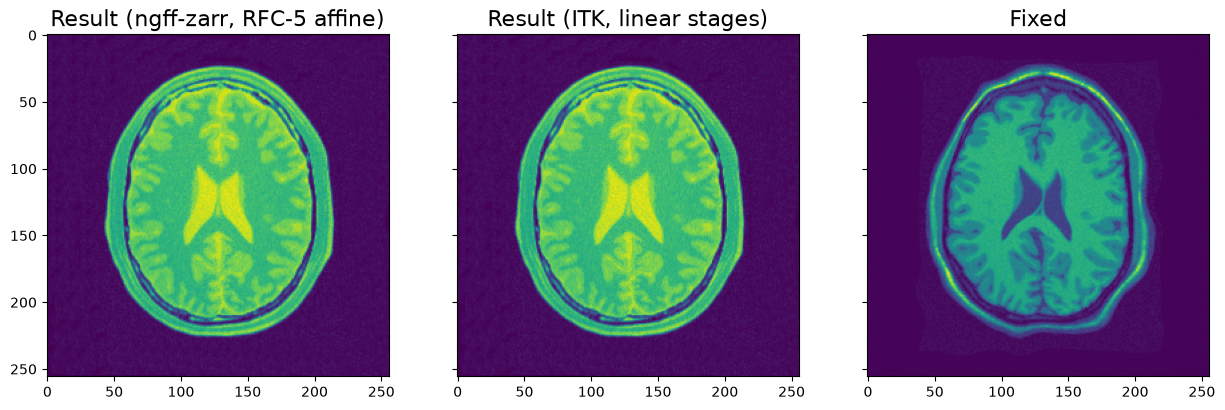

In [16]:
fig, axs = plt.subplots(1, 3, sharey=True, figsize=[15, 5])
axs[0].imshow(ngff_linear_array)
axs[0].set_title("Result (ngff-zarr, RFC-5 affine)", fontsize=16)
axs[1].imshow(itk_linear_result)
axs[1].set_title("Result (ITK, linear stages)", fontsize=16)
axs[2].imshow(fixed_image)
axs[2].set_title("Fixed", fontsize=16)
plt.show()

## Deformable Registration Results to an RFC-5 `displacements` Field

The B-spline stage has no affine equivalent. RFC-5 represents deformations as a **displacement field**: an image with one *displacement* component per spatial axis, stored as its own multiscales inside the OME-Zarr group, which a `displacements` transformation points at by `path`. The transformation adds the interpolated displacement to each input point.

ITK's `TransformToDisplacementFieldFilter` samples any transform, including our full composite transform, on a reference grid. Sampling it on the fixed image grid gives the total fixed-to-moving displacement at every fixed pixel. `itk_displacement_field_to_ngff_transform` converts that field to an `NgffImage` in RFC-5 layout, with the component axis first and the components in `dims` order, and returns the `displacements` transformation along with it.

In [17]:
displacement_field = itk.transform_to_displacement_field_filter(
    itk_composite_transform,
    use_reference_image=True,
    reference_image=fixed_image,
)
print(type(displacement_field).__name__, itk.size(displacement_field))

itkImageVF22 itkSize2 ([256, 256])


In [18]:
displacements, field = nz.itk_displacement_field_to_ngff_transform(
    displacement_field,
    fixed_ngff.dims,
    path="displacement_field",
    fixed=fixed_ngff,
    moving=moving_ngff,
)
print(displacements)
print("field dims:", field.dims, "shape:", field.data.shape, "axes_types:", field.axes_types)

Displacements(input=None, output=None, name=None, type='displacements', path='displacement_field', interpolation='linear')
field dims: ('c', 'y', 'x') shape: (2, 256, 256) axes_types: {'c': 'displacement'}


The field is written first, as a subgroup of the image's store at the transformation's `path`. The image is then written at the root of the store with `overwrite=False`, so that the field is kept.

In [19]:
deformable_store = "exampleoutput/registered_deformable.ome.zarr"
shutil.rmtree(deformable_store, ignore_errors=True)

field_multiscales = nz.to_multiscales(field, scale_factors=[])
nz.to_ome_zarr(f"{deformable_store}/{displacements.path}", field_multiscales, version="0.6")

deformable_multiscales = nz.to_multiscales(fixed_ngff, scale_factors=[])
intrinsic = deformable_multiscales.metadata.intrinsic_coordinate_system
moving_system = CoordinateSystem(name="moving", axes=list(intrinsic.axes))
deformable_multiscales.metadata.coordinateSystems.append(moving_system)

displacements.name = "fixed_to_moving"
displacements.input = CoordinateSystemIdentifier(name=intrinsic.name)
displacements.output = CoordinateSystemIdentifier(name=moving_system.name)
deformable_multiscales.metadata.coordinateTransformations = [displacements]
nz.to_ome_zarr(deformable_store, deformable_multiscales, version="0.6", overwrite=False)

show_ome_metadata(deformable_store, keys=("coordinateTransformations",))
print("Store contents:", sorted(path.name for path in Path(deformable_store).iterdir()))

{
  "version": "0.6",
  "coordinateTransformations": [
    {
      "input": {
        "name": "intrinsic"
      },
      "output": {
        "name": "moving"
      },
      "name": "fixed_to_moving",
      "type": "displacements",
      "path": "displacement_field",
      "interpolation": "linear"
    }
  ]
}
Store contents: ['displacement_field', 'scale0', 'zarr.json']


The field's own multiscales metadata marks its first axis with `type: "displacement"`, one component per spatial axis of the coordinate system it displaces:

In [20]:
show_ome_metadata(f"{deformable_store}/{displacements.path}", keys=("coordinateSystems",))

{
  "version": "0.6",
  "coordinateSystems": [
    {
      "name": "intrinsic",
      "axes": [
        {
          "name": "c",
          "type": "displacement",
          "discrete": true
        },
        {
          "name": "y",
          "type": "space",
          "orientation": {
            "value": "anterior-to-posterior",
            "type": "anatomical"
          }
        },
        {
          "name": "x",
          "type": "space",
          "orientation": {
            "value": "right-to-left",
            "type": "anatomical"
          }
        }
      ]
    }
  ]
}


Reading the store back resolves both the transformation and its field. `nz.resample` accepts the field through `fields`, keyed by the transformation's `path`, and streams it chunk by chunk just like the moving image. The result matches ITK resampling through the full composite transform.

In [21]:
read_back = nz.from_ome_zarr(deformable_store)
displacements_from_store = read_back.metadata.coordinateTransformations[0]
field_from_store = nz.from_ome_zarr(f"{deformable_store}/{displacements_from_store.path}")

ngff_deformable_result = nz.resample(
    displacements_from_store,
    fixed_ngff,
    moving_ngff,
    fields={displacements_from_store.path: field_from_store},
)
ngff_deformable_array = np.asarray(ngff_deformable_result.data)

itk_deformable_result = itk.resample_image_filter(
    moving_image,
    transform=itk_composite_transform,
    use_reference_image=True,
    reference_image=fixed_image,
)
difference = ngff_deformable_array - itk.array_from_image(itk_deformable_result)
print("Max abs difference, ngff-zarr vs ITK:", np.abs(difference).max())

Max abs difference, ngff-zarr vs ITK: 3.0517578e-05


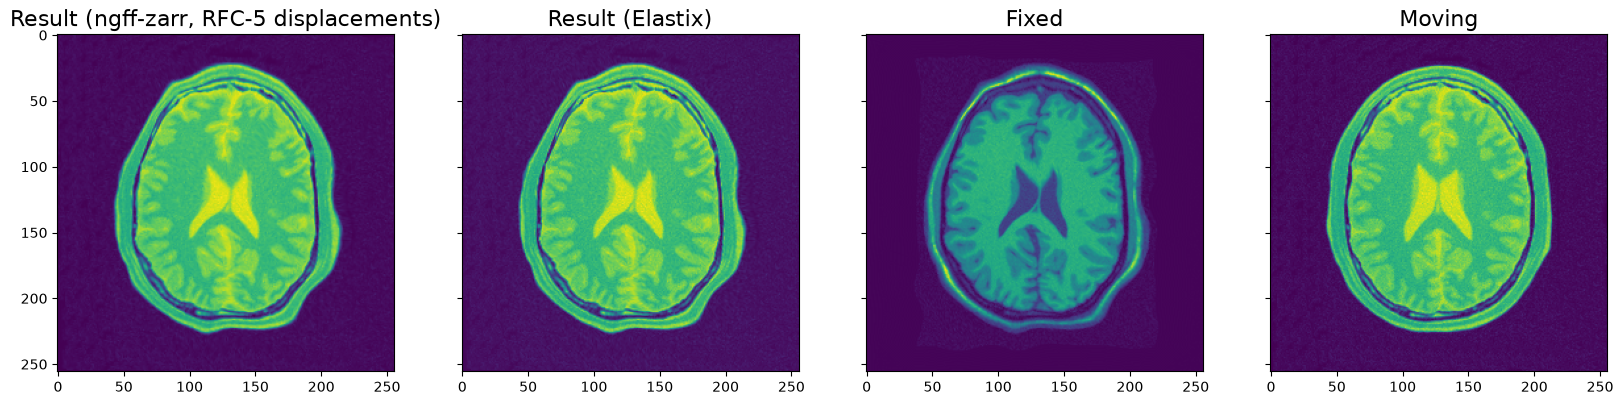

In [22]:
# Compare with the Elastix result image. Some differences exist in default interpolation methods:
# Elastix resamples with a cubic B-spline interpolator, ngff-zarr with a linear one.
fig, axs = plt.subplots(1, 4, sharey=True, figsize=[20, 5])
axs[0].imshow(ngff_deformable_array)
axs[0].set_title("Result (ngff-zarr, RFC-5 displacements)", fontsize=16)
axs[1].imshow(elx_result_image)
axs[1].set_title("Result (Elastix)", fontsize=16)
axs[2].imshow(fixed_image)
axs[2].set_title("Fixed", fontsize=16)
axs[3].imshow(moving_image)
axs[3].set_title("Moving", fontsize=16)
plt.show()

## Save the Transformation on Its Own

Example 22 saved the ITK composite transform to an HDF5 file. The OME-Zarr counterpart of a standalone transform file is a store that holds only the displacement field. `declare_field_transform` declares a spatial coordinate system from the field's own axes and a `displacements` transformation from that system onto itself: the total fixed-to-moving field, ready to be applied to any image expressed in the same physical coordinates.

In [23]:
field_store = "exampleoutput/fixed_to_moving_displacement_field.ome.zarr"
shutil.rmtree(field_store, ignore_errors=True)

standalone_field = nz.declare_field_transform(field_multiscales)
nz.to_ome_zarr(field_store, standalone_field, version="0.6")

show_ome_metadata(field_store)

{
  "version": "0.6",
  "coordinateSystems": [
    {
      "name": "intrinsic",
      "axes": [
        {
          "name": "c",
          "type": "displacement",
          "discrete": true
        },
        {
          "name": "y",
          "type": "space",
          "orientation": {
            "value": "anterior-to-posterior",
            "type": "anatomical"
          }
        },
        {
          "name": "x",
          "type": "space",
          "orientation": {
            "value": "right-to-left",
            "type": "anatomical"
          }
        }
      ]
    },
    {
      "name": "physical",
      "axes": [
        {
          "name": "y",
          "type": "space"
        },
        {
          "name": "x",
          "type": "space"
        }
      ]
    }
  ],
  "coordinateTransformations": [
    {
      "input": {
        "name": "physical"
      },
      "output": {
        "name": "physical"
      },
      "type": "displacements",
      "path": "scale0/displaceme

## Summary

| Registration result | ITK representation | RFC-5 transformation | Converter |
| --- | --- | --- | --- |
| Translation, rigid, similarity and affine stages | `itk.CompositeTransform` of `MatrixOffsetTransformBase` subclasses | `affine` (or `translation`, `scale`, `identity` when simpler) | `ngff_zarr.itk_transform_to_ngff_transform` |
| B-spline or any other deformable stage | `itk.BSplineTransform`, `itk.DisplacementFieldTransform` or a vector image | `displacements` field | `ngff_zarr.itk_displacement_field_to_ngff_transform` |

Further reading:

- [RFC-5: Coordinate Systems and Transformations in ngff-zarr](https://ngff-zarr.readthedocs.io/en/latest/rfc5.html)
- [ngff-zarr and the Insight Toolkit](https://ngff-zarr.readthedocs.io/en/latest/itk.html)
- [The OME-NGFF specification](https://ngff.openmicroscopy.org/latest/)
- [ITK Software Guide: Transforms](https://itk.org/ITKSoftwareGuide/html/Book2/ITKSoftwareGuide-Book2ch3.html)